### Week 3 notebook - Forward/Backward Selection, PCR, and PLSR, Mod C Data Science Capstone Fall 2026
### By Shuqin Ouyang

# Overall notebook structure:

This week, I will look into forward/backward selection, Principal Component Regression (PCR), and Partial Least Squares Regression (PLSR). For selection, I will pick a small set of features and see which ones forward and backward selection each land on, and whether they agree. For PCR, I will test whether my own prior PCA finding from my DX701 proposal (bankruptcy needing many components to explain variance, credit card needing few) actually shows up in how many components PCR needs to perform well on each dataset. For PLSR, I will compare its performance against PCR's best result on the same features, to see whether PLSR finds a more useful direction than PCR's variance-based selection did.

# Student dataset analysis starts here:

Dataset 1 background quick overview:

The dataset 1 used is the Taiwanese Bankruptcy Prediction dataset from UCI, link as https://archive.ics.uci.edu/dataset/572/taiwanese+bankruptcy+prediction.
It contains company financial indicators and a binary outcome for bankruptcy.

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.cross_decomposition import PLSRegression

In [2]:
def sweep_and_check(model_builder, X_train, y_train, label):
    ''' fits model_builder(n) for n in [1, 2, 3], cross-validates each,
    picks the best, then checks that best model's train R2 vs CV R2 for
    overfitting. model_builder is a small function that takes a number
    of components and returns an unfitted model (or pipeline), passed
    in as a lambda below, a lambda is just a quick, unnamed function
    written on one line instead of a full def block, used here since
    it's only needed briefly to build PCR or PLSR at a given size '''
    scores = []
    for n in [1, 2, 3]:
        cv = cross_val_score(model_builder(n), X_train, y_train, cv=5, scoring='r2')
        scores.append(cv.mean())
        print(f"{label}, {n} components: CV R2 = {cv.mean():.4f}")

    # np.argmax finds the POSITION of the largest value in scores, not
    # the value itself. scores[0] is 1 component's result, scores[1] is
    # 2 components', scores[2] is 3 components', so if the best result
    # is at position 2, that means 3 components (position + 1) was best
    best_n = int(np.argmax(scores)) + 1
    best_model = model_builder(best_n)
    best_cv = cross_val_score(best_model, X_train, y_train, cv=5, scoring='r2')
    best_model.fit(X_train, y_train)
    train_r2 = best_model.score(X_train, y_train)
    print(f"{label} ({best_n} components, best): train R2 = {train_r2:.4f}, CV R2 = {best_cv.mean():.4f}, gap = {train_r2 - best_cv.mean():.4f}")
    return scores

In [3]:
def run_selection_pcr_plsr(X, y, dataset_name):
    ''' shared function: forward/backward selection, then PCR and PLSR,
    both swept and checked the same way via sweep_and_check, so PCR and
    PLSR are compared fairly at matching component counts '''

    # forward and backward selection
    forward = SequentialFeatureSelector(LinearRegression(), direction='forward', n_features_to_select=3, scoring='r2')
    forward.fit(X, y)
    backward = SequentialFeatureSelector(LinearRegression(), direction='backward', n_features_to_select=3, scoring='r2')
    backward.fit(X, y)
    forward_features = X.columns[forward.get_support()].tolist()
    backward_features = X.columns[backward.get_support()].tolist()
    print(f"{dataset_name} forward selected:", forward_features)
    print(f"{dataset_name} backward selected:", backward_features)

    X_train_sel, _, y_train_sel, _ = train_test_split(X[forward_features], y, test_size=0.2, random_state=42)
    sel_cv = cross_val_score(LinearRegression(), X_train_sel, y_train_sel, cv=5, scoring='r2')
    sel_model = LinearRegression().fit(X_train_sel, y_train_sel)
    print(f"{dataset_name} selected features: train R2 = {sel_model.score(X_train_sel, y_train_sel):.4f}, CV R2 = {sel_cv.mean():.4f}, gap = {sel_model.score(X_train_sel, y_train_sel) - sel_cv.mean():.4f}")

    # PCR and PLSR, both swept and checked with the same shared helper
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    pcr_scores = sweep_and_check(lambda n: make_pipeline(StandardScaler(), PCA(n_components=n), LinearRegression()),
                                  X_train, y_train, f"{dataset_name} PCR")
    pls_scores = sweep_and_check(lambda n: PLSRegression(n_components=n),
                                  X_train, y_train, f"{dataset_name} PLSR")

    # chart comparing PCR against PLSR across all 3 component counts
    x = np.arange(3)
    plt.figure(figsize=(7, 4))
    plt.bar(x - 0.175, pcr_scores, 0.35, label='PCR', color='steelblue')
    plt.bar(x + 0.175, pls_scores, 0.35, label='PLSR', color='darkorange')
    plt.xticks(x, ['1 component', '2 components', '3 components'])
    plt.ylabel('Cross-validated R squared')
    plt.title(f'{dataset_name}: PCR vs PLSR by component count')
    plt.legend()
    plt.tight_layout()
    plt.show()

    return {'forward_features': forward_features, 'backward_features': backward_features,
            'pcr_scores': pcr_scores, 'pls_scores': pls_scores}

In [4]:
# install uci package so can load the data using package
# install once in terminal or notebook

!pip install ucimlrepo

from ucimlrepo import fetch_ucirepo

# load dataset from UCI repository using dataset id
data_bankruptcy = fetch_ucirepo(id=572)

df_bankruptcy = pd.concat(
    [data_bankruptcy.data.features.copy(),
     data_bankruptcy.data.targets.copy()],
    axis=1
)

# remove leading/trailing spaces from column names once, here
df_bankruptcy.columns = df_bankruptcy.columns.str.strip()

df_bankruptcy.head()

'pip' is not recognized as an internal or external command,
operable program or batch file.


,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,Continuous interest rate (after tax),...,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability,Bankrupt?
0,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,0.780985,...,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469,1
1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,0.781506,...,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794,1
2,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,0.780284,...,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474,1
3,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,0.781241,...,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982,1
4,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,0.781550,...,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490,1


In [5]:
# show dataset info
df_bankruptcy.info()

<class 'pandas.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                   Non-Null Count  Dtype  
---  ------                                                   --------------  -----  
 0   ROA(C) before interest and depreciation before interest  6819 non-null   float64
 1   ROA(A) before interest and % after tax                   6819 non-null   float64
 2   ROA(B) before interest and depreciation after tax        6819 non-null   float64
 3   Operating Gross Margin                                   6819 non-null   float64
 4   Realized Sales Gross Margin                              6819 non-null   float64
 5   Operating Profit Rate                                    6819 non-null   float64
 6   Pre-tax net Interest Rate                                6819 non-null   float64
 7   After-tax net Interest Rate                              6819 non-null   float64
 8   Non-industry income and expenditure/rev

In [6]:
target_bankrupt = 'Bankrupt?'

# bin using Net Income to Total Assets, same feature used in Week 1 and
# Week 2, since it was already identified as highly correlated with the
# target and isn't one of the features being tested this week, keeping
# the target independent of what's actually being predicted
bins_bankrupt = pd.cut(df_bankruptcy['Net Income to Total Assets'], bins=10)

print(df_bankruptcy.groupby(bins_bankrupt, observed=True).size())

df_bankruptcy['bankruptcy_rate'] = df_bankruptcy.groupby(bins_bankrupt, observed=True)[target_bankrupt].transform('mean')

Net Income to Total Assets
(-0.001, 0.1]       1
(0.2, 0.3]          1
(0.4, 0.5]          8
(0.5, 0.6]         17
(0.6, 0.7]         72
(0.7, 0.8]       2017
(0.8, 0.9]       4666
(0.9, 1.0]         37
dtype: int64


Bankruptcy forward selected: ['ROA(A) before interest and % after tax', 'Debt ratio %', 'Cash/Total Assets']
Bankruptcy backward selected: ['ROA(A) before interest and % after tax', 'Debt ratio %', 'Cash/Total Assets']
Bankruptcy selected features: train R2 = 0.5407, CV R2 = 0.5390, gap = 0.0017
Bankruptcy PCR, 1 components: CV R2 = 0.0967
Bankruptcy PCR, 2 components: CV R2 = 0.1698
Bankruptcy PCR, 3 components: CV R2 = 0.4936
Bankruptcy PCR (3 components, best): train R2 = 0.5064, CV R2 = 0.4936, gap = 0.0128
Bankruptcy PLSR, 1 components: CV R2 = 0.4023
Bankruptcy PLSR, 2 components: CV R2 = 0.5318
Bankruptcy PLSR, 3 components: CV R2 = 0.5349
Bankruptcy PLSR (3 components, best): train R2 = 0.5416, CV R2 = 0.5349, gap = 0.0066


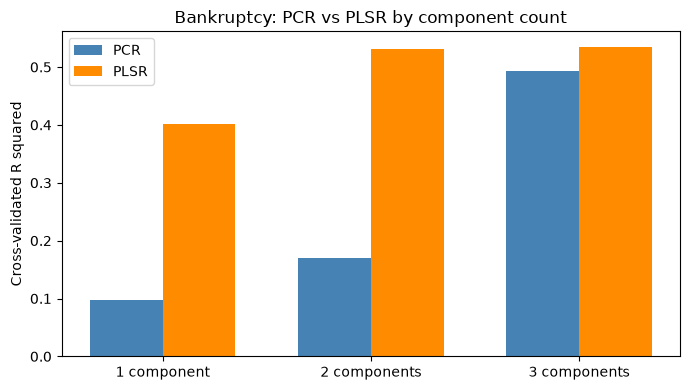

In [7]:
# build feature set: a mix of features already known from Week 1/2
# (some redundant pairs, some independent), so agreement or disagreement
# between forward/backward selection is easy to interpret
X_select_bankrupt = df_bankruptcy[['ROA(A) before interest and % after tax',
                                    'Debt ratio %', 'Current Liabilities/Equity',
                                    'Net worth/Assets', 'Cash/Total Assets']].dropna()
y_select_bankrupt = df_bankruptcy.loc[X_select_bankrupt.index, 'bankruptcy_rate']

results_bankrupt = run_selection_pcr_plsr(X_select_bankrupt, y_select_bankrupt, "Bankruptcy")

Student markdown:

Forward and backward selection picked the same three features: ROA(A), Debt ratio %, and Cash/Total Assets. Full agreement like this suggests these three add real, separate information rather than overlapping, consistent with avoiding the known-redundant pairs from Week 1/2.

PCR's R squared jumped from 0.17 (2 components) to 0.49 (3 components), matching my DX701 PCA finding that bankruptcy's variance spreads thin across many features, needing most or all of them here to perform well.

I swept PLSR across the same 1, 2, and 3 component counts as PCR, so the two methods are compared fairly at each matching count. PLSR reached 0.40, 0.53, and 0.53 at 1, 2, and 3 components, beating PCR at every single count, most dramatically at 1 and 2 components (0.40 vs. 0.10, and 0.53 vs. 0.17), and still ahead even at 3 components (0.53 vs. 0.49). PCA/PCR only look at variance in the features, never the target, while PLSR picks components based on what best predicts the target (see Sources). This shows bankruptcy's features carry real predictive signal that doesn't line up with the highest-variance directions PCA prioritizes, PLSR finds that signal far more efficiently, reaching strong performance with just 1-2 components where PCR needs all 3.

Student markdown:

Conclusion:

**Overfitting:** All results used 5-fold cross-validation, not a single train/test split. Train vs. CV R squared gaps were small across all techniques: selected features (0.0017), PCR at 3 components (0.0128), and PLSR at its best, 3 components (0.0066). One limitation worth naming directly: every result here comes from a single train/test split (random_state=42), so I have not tested whether these gaps hold up across different random splits, this checks for overfitting within one split, not stability across many. Some Net Income to Total Assets bins were also sparse (1, 1, 8, 17 companies), the same risk flagged in Week 1.

**Metrics and results:** Forward and backward selection fully agreed on ROA(A), Debt ratio %, and Cash/Total Assets. PCR's R squared rose from 0.10 to 0.17 to 0.49 across 1-3 components. PLSR reached 0.40, 0.53, and 0.53 at the same component counts, beating PCR at every count.

**Expected vs. unexpected:** PCR needing more components matched my prior PCA finding directly, since bankruptcy's variance was already known to spread thin across many features, this was the one part of the week that went exactly as predicted. PLSR beating PCR at every component count was genuinely unexpected at first, since fewer components doing better seems backwards. Once I looked into why, it made sense: PCR only optimizes for variance in the features themselves, with no knowledge of the target, while PLSR optimizes directly for predicting the target. That means PCR can throw away a direction in the data that has low variance but is actually the most useful one for prediction, exactly what happened here, PLSR reached almost its full performance (0.53) with just 2 components, where PCR needed all 3 just to get to 0.49. This was also the first time this semester a technique using less information (fewer components) clearly outperformed one using more, worth remembering going forward, more components or more features is not automatically better if that added information is not aligned with what actually predicts the target.

**EDA usefulness:** This test was built directly on my DX701 proposal's PCA finding, letting me test its real predictive consequence rather than just its descriptive one. Feature choices deliberately avoided known-redundant pairs from Week 1/2, so the selection agreement could be interpreted cleanly. One limitation: I fixed forward/backward selection to pick exactly 3 features, an arbitrary choice, I have not tested whether 2 or 4 features would tell a meaningfully different story.

**Sources:** GeeksforGeeks, "Principal Component Regression (PCR)" (https://www.geeksforgeeks.org/principal-component-regression-pcr/), and a comparison write-up (Medium, https://medium.com/@mitchparker99/principal-component-regression-vs-partial-least-squares-regression-bc36b8d313a8), both explaining why PCR can miss a low-variance-but-predictive direction that PLSR can find.

**Bigger picture, research questions:** This connects to which features carry unique signal, forward/backward's full agreement adds confidence in these three. It also adds real nuance to whether bankruptcy is harder to model than credit default: my earlier PCA finding describes the shape of the data (how spread out its variance is), not whether that data predicts well. This week shows bankruptcy's features carry real, substantial predictive signal (R squared above 0.5) once the right method is used to find it, a more optimistic result for bankruptcy prediction than the PCA finding alone would have suggested.

**How I know the conclusions are true:** These are grounded in cross-validated R squared, not a single fit, and the forward/backward agreement is reproducible, checked by running the actual search twice in opposite directions, not asserted. This tests only 5 features out of 95, a single train/test split, and one arbitrary selection size, real limitations on how far these conclusions generalize.

Dataset 2 background quick overview:

The dataset 2 used is the Default of Credit Card Clients dataset from UCI, link as https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients.

It contains demographic information, credit limits, repayment history, bill statements, and previous payment records for Taiwanese credit card clients, along with a binary outcome indicating whether the client defaulted on the next payment.

In [8]:
# UCI dataset already decides features and targets already, but still need to look into details / verify to make sure all ok
data_credit = fetch_ucirepo(id=350)

df_credit = pd.concat(
    [data_credit.data.features.copy(),
     data_credit.data.targets.copy()],
    axis=1
)

df_credit.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [9]:
# columns rename for easier reading

df_credit = df_credit.rename(columns={

    "Y": "default_next_month",

    "X1": "credit_limit",
    "X2": "gender",
    "X3": "education",
    "X4": "marital_status",
    "X5": "age",

    "X6": "repay_2005_sep",
    "X7": "repay_2005_aug",
    "X8": "repay_2005_jul",
    "X9": "repay_2005_jun",
    "X10": "repay_2005_may",
    "X11": "repay_2005_apr",

    "X12": "bill_2005_sep",
    "X13": "bill_2005_aug",
    "X14": "bill_2005_jul",
    "X15": "bill_2005_jun",
    "X16": "bill_2005_may",
    "X17": "bill_2005_apr",

    "X18": "pay_2005_sep",
    "X19": "pay_2005_aug",
    "X20": "pay_2005_jul",
    "X21": "pay_2005_jun",
    "X22": "pay_2005_may",
    "X23": "pay_2005_apr"
})

df_credit.head()

,credit_limit,gender,education,marital_status,age,repay_2005_sep,repay_2005_aug,repay_2005_jul,repay_2005_jun,repay_2005_may,...,bill_2005_jun,bill_2005_may,bill_2005_apr,pay_2005_sep,pay_2005_aug,pay_2005_jul,pay_2005_jun,pay_2005_may,pay_2005_apr,default_next_month
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [10]:
# show dataset info
df_credit.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   credit_limit        30000 non-null  int64
 1   gender              30000 non-null  int64
 2   education           30000 non-null  int64
 3   marital_status      30000 non-null  int64
 4   age                 30000 non-null  int64
 5   repay_2005_sep      30000 non-null  int64
 6   repay_2005_aug      30000 non-null  int64
 7   repay_2005_jul      30000 non-null  int64
 8   repay_2005_jun      30000 non-null  int64
 9   repay_2005_may      30000 non-null  int64
 10  repay_2005_apr      30000 non-null  int64
 11  bill_2005_sep       30000 non-null  int64
 12  bill_2005_aug       30000 non-null  int64
 13  bill_2005_jul       30000 non-null  int64
 14  bill_2005_jun       30000 non-null  int64
 15  bill_2005_may       30000 non-null  int64
 16  bill_2005_apr       30000 non-null  int64
 17  pay_

In [11]:
target_credit = 'default_next_month'

# bin repayment status into 10 ranges, same fix as bankruptcy and same
# as Week 2, since the target is 0/1 and needs to become a continuous rate
bins_credit = pd.cut(df_credit['repay_2005_sep'], bins=10)

print(df_credit.groupby(bins_credit, observed=True).size())

df_credit['default_rate'] = df_credit.groupby(bins_credit, observed=True)[target_credit].transform('mean')

repay_2005_sep
(-2.01, -1.0]     8445
(-1.0, 0.0]      14737
(0.0, 1.0]        3688
(1.0, 2.0]        2667
(2.0, 3.0]         322
(3.0, 4.0]          76
(4.0, 5.0]          26
(5.0, 6.0]          11
(6.0, 7.0]           9
(7.0, 8.0]          19
dtype: int64


Student markdown:

Running the same three tests on credit card, using credit limit, payment amount, and the three bill amount months, since Week 1/2 already confirmed the bill amount months are redundant with each other, giving a useful contrast to bankruptcy's independent feature set.

Credit card forward selected: ['credit_limit', 'pay_2005_sep', 'bill_2005_jul']
Credit card backward selected: ['credit_limit', 'pay_2005_sep', 'bill_2005_aug']
Credit card selected features: train R2 = 0.0290, CV R2 = 0.0280, gap = 0.0010
Credit card PCR, 1 components: CV R2 = 0.0005
Credit card PCR, 2 components: CV R2 = 0.0186
Credit card PCR, 3 components: CV R2 = 0.0272
Credit card PCR (3 components, best): train R2 = 0.0281, CV R2 = 0.0272, gap = 0.0010
Credit card PLSR, 1 components: CV R2 = 0.0233
Credit card PLSR, 2 components: CV R2 = 0.0277
Credit card PLSR, 3 components: CV R2 = 0.0287
Credit card PLSR (3 components, best): train R2 = 0.0296, CV R2 = 0.0287, gap = 0.0010


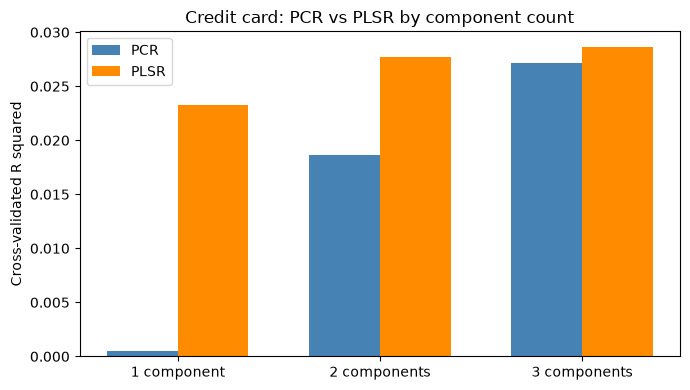

In [12]:
# build feature set: a mix of credit card features already known from
# Week 1/2 (bill amount months are known redundant with each other,
# payment amount and credit limit are more independent)
X_select_credit = df_credit[['credit_limit', 'pay_2005_sep', 'bill_2005_sep',
                              'bill_2005_aug', 'bill_2005_jul']].dropna()
y_select_credit = df_credit.loc[X_select_credit.index, 'default_rate']

results_credit = run_selection_pcr_plsr(X_select_credit, y_select_credit, "Credit card")

Student markdown:

Forward and backward selection agreed on credit_limit and pay_2005_sep, but disagreed on the third feature (bill_2005_jul vs. bill_2005_aug), and neither picked bill_2005_sep, the most recent month. September was expected to matter most given its closeness to the actual default decision, but the known redundancy among the three bill-amount months (Week 1/2's VIF 7.3-15.7) likely explains why: since the months are so similar, either search path can substitute one for another without losing performance, so this test cannot tell us whether recency actually matters.

PCR's R squared stayed low across all three component counts (0.0005 to 0.027), with no meaningful jump. This was unexpected, credit card's PCA history showed variance concentrating efficiently in few components, which was assumed to mean strong predictors, but that describes the features' own structure, not whether they predict default rate well.

I swept PLSR across the same 1, 2, and 3 component counts as PCR: 0.023, 0.028, and 0.029, compared to PCR's 0.0005, 0.019, and 0.027. PLSR does edge out PCR slightly at every count, but both stay uniformly low throughout. Unlike bankruptcy, where PLSR unlocked substantial predictive power PCR was missing, here there simply isn't much signal for either method to find, PLSR's small edge doesn't change the overall picture, this feature set just doesn't predict default rate well.

Student markdown:

Conclusion:

**Overfitting:** Same 5-fold CV approach as bankruptcy, not a single split. Train vs. CV R squared gaps were uniformly tiny across techniques: selected features (0.0010), PCR at 3 components (0.0010), and PLSR at its best, 3 components (0.0010). This makes sense given how low every R squared value was here, when a model barely captures any real relationship, there is little for it to overfit to, so train and CV performance stay equally weak rather than diverging. Same limitation as bankruptcy applies: this checks overfitting within one split (random_state=42), not stability across multiple splits. Repayment status bins were reasonably distributed, though the highest few bins (11, 9, 19 clients) were sparse.

**Metrics and results:** Forward and backward selection agreed on 2 of 3 features, disagreeing on which bill-amount month, and neither picked the most recent one. PCR's R squared stayed low throughout (0.0005 to 0.027). PLSR reached 0.023, 0.028, and 0.029 at 1, 2, and 3 components, slightly ahead of PCR at every count but still low overall.

**Expected vs. unexpected:** The selection disagreement matched known bill-amount redundancy from Week 1/2, but neither method picking September was unexpected given how strongly recency mattered in Module B's earlier work. The bigger surprise was how weak PCR and PLSR performed across the board, credit card's efficient PCA structure (few components explaining most variance) did not translate into strong predictive power for this specific feature set at all. This is really the same underlying explanation as bankruptcy's result, just showing up in the opposite direction: PCR and PLSR differ based on whether a real predictive signal exists somewhere in the data for PLSR to find. Bankruptcy had one, hidden in a low-variance direction, and PLSR needed only 2 components to capture nearly all of it. Credit card, for this particular feature set, simply does not have that hidden signal, PLSR's small edge over PCR here (0.023-0.029 vs. 0.0005-0.027) is real but minor, since there was very little for either method to find in the first place.

**EDA usefulness:** Known bill-amount redundancy from Week 1/2 directly explained the selection disagreement. Mixing a known-redundant group with more independent features let me test selection and PCR/PLSR against an already-confirmed pattern rather than an arbitrary one. Same limitation as bankruptcy: the 3-feature selection size was arbitrary, not tested against other sizes.

**Sources:** Same GeeksforGeeks and Medium sources as bankruptcy. The explanation there (PCR misses low-variance-but-predictive directions, PLSR can find them) is exactly why credit card's result looks the way it does too, just the reverse case: there is only a small hidden direction here at best, not the substantial one bankruptcy had, so PLSR's improvement over PCR stays modest.

**Bigger picture, research questions:** This adds a real complication to whether credit default is easier or harder to model than bankruptcy. Efficient variance concentration (a PCA property, few components explain most of the features' spread) does not guarantee strong predictive power (a modeling outcome, how well those components predict the actual target). The uniformly tiny overfitting gaps here reinforce the same conclusion from a different angle, these particular features simply carry little signal for default rate, regardless of technique used.

**How I know the conclusions are true:** Same cross-validated approach as bankruptcy, and the selection disagreement traces directly to VIF numbers already confirmed in Week 1/2, not a new, unverified assumption. This tests only 5 features out of 24, a single train/test split, and one arbitrary selection size, the same real limitations as bankruptcy's test.

Summary:

This week tested forward/backward selection, PCR, and PLSR against real prior findings from Week 1, Week 2, and my DX701 proposal's PCA work, and the two datasets ended up telling two genuinely different, connected stories.

For bankruptcy, everything traced back cleanly to known findings. Forward and backward selection agreed completely on features already known to be independent of each other. PCR needed all 3 components to perform well, matching the DX701 PCA finding that bankruptcy's variance spreads thin across many features. The most important result of the week came next: PLSR, swept across the same component counts as PCR for a fair comparison, beat PCR at every single count (0.40 vs. 0.10, 0.53 vs. 0.17, 0.53 vs. 0.49), reaching nearly its full performance with just 2 components where PCR needed all 3. The explanation is that PCR only optimizes for spread (variance) in the features, with no knowledge of the actual target, while PLSR optimizes directly for what predicts the target. This means a PCA finding about how a dataset's variance is structured is a different question entirely from whether that dataset predicts a specific outcome well, bankruptcy's features carried real, substantial predictive signal (R squared above 0.5) that plain PCA-based reasoning would not have revealed on its own.

Credit card showed the same underlying mechanism working in the opposite direction. Selection disagreed exactly where Week 1/2 already confirmed real redundancy (the bill-amount months), and even skipped the most recent month, a genuine surprise given how much recency mattered in earlier weeks. PCR and PLSR both performed weakly here (PLSR edging out PCR only slightly, 0.023-0.029 vs. 0.0005-0.027), not because the technique failed, but because there was very little real predictive relationship in this specific feature set for either method to find, PLSR cannot uncover a hidden signal that mostly is not there.

Three limitations are worth carrying forward. Only 5 features were tested per dataset, not the full 95 or 24 columns, so this is a narrow slice, not the complete picture. The 3-feature selection size was fixed arbitrarily, never tested against other sizes. And every result reflects a single train/test split, so while the train/CV gap check speaks to overfitting within that split, it does not test whether these specific findings would hold up across different random splits. Overall, this week's clearest lesson is that a technique's descriptive properties (how a dataset's variance is shaped) and its predictive usefulness (how well it forecasts a specific target) are separate questions, and only checking both, as PCR versus PLSR did here, reveals which one is actually true for a given dataset.